### Anova Test(Analysis Variance)
* It compares all the groups in the data where as Z & T tests compares only 2 groups.
* It is of 2 types: 
    * 1-way anova &
    * 2-way anova
* The ANOVA is also used to test the statistical significance of a linear regression model

### Post Hoc Test
* Anova never tells which specific group differs to resolve this post hoc test is needed.
* Ex: comparision of 4 groups we get 6 pairs(1&2,1&3,1&4 and 2&3,2&4 and 3&4).
    * to find which pair is different we should do pair wise comparision thats the Post Hoc test.

![![image.png]](attachment:image.png)
Anova table for the Manual Calculation for the Data
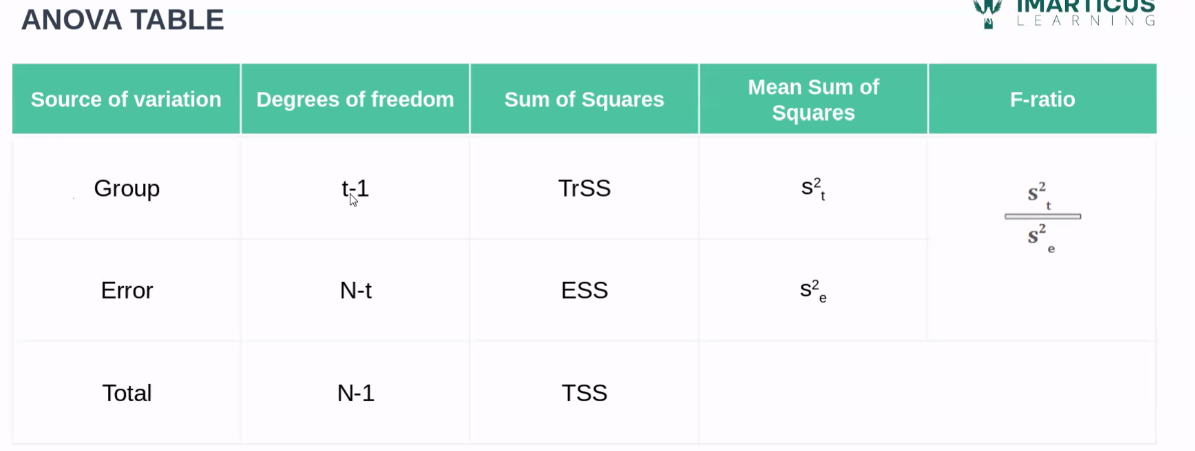

### Practcie Test Question 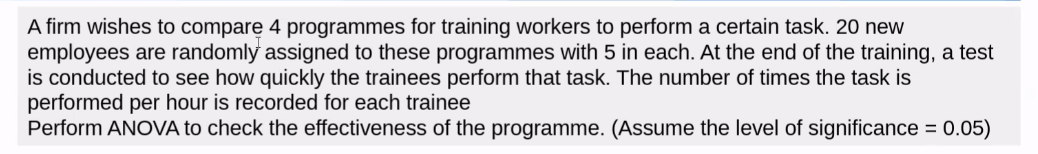

In [ ]:
from scipy import stats
import numpy as np

# Example data for groups (replace with your actual data)
group1 = np.array([9,12,14,11,13])  # Add your group 1 values
group2 = np.array([10,6,9,9,10])  # Add your group 2 values
group3 = np.array([12,14,11,13,11]) # Add your group 3 values
group4 = np.array([9,8,11,7,8])  # Add your group 4 values

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(group1, group2, group3, group4)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")
# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - groups differ significantly")
else:
    print("Fail to reject the null hypothesis - no significant difference")
    
### Conclusion: Based on the ANOVA test, if the p-value is less than 0.05, we reject the null hypothesis, indicating that there is a statistically significant difference between the groups

F-statistic: 7.044871794871795
P-value: 0.0031129438989961756
Reject the null hypothesis - groups differ significantly


Post Hoc test types:
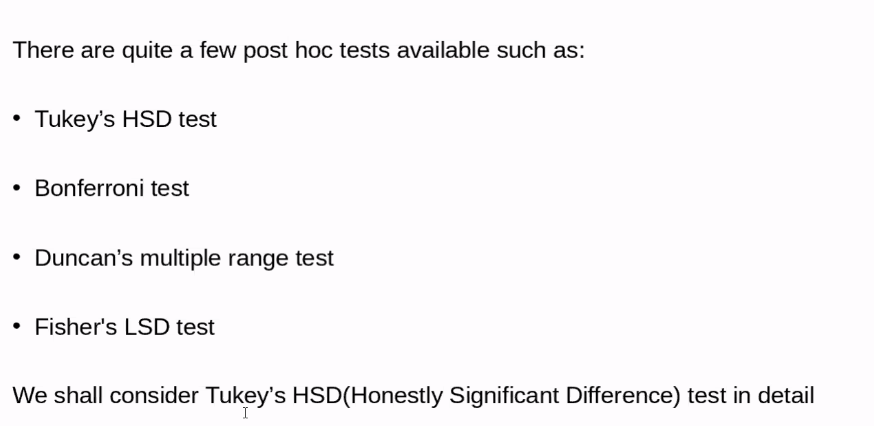

In [5]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pandas as pd 
df_programme = pd.DataFrame({"group1": np.array([9,12,14,11,13]),  # Add your group 1 values
                             "group2": np.array([10,6,9,9,10]),  # Add your group 2 values
                             "group3": np.array([12,14,11,13,11]), # Add your group 3 values
                             "group4": np.array([9,8,11,7,8]) })
df_stacked = df_programme.stack().reset_index()
df_stacked= df_stacked.rename(columns={"level_0": "id", "level_1": "group", 0: "number of tasks"})
mc = MultiComparison(df_stacked["number of tasks"], df_stacked["group"])
result = mc.tukeyhsd().summary()
result

group1,group2,meandiff,p-adj,lower,upper,reject
group1,group2,-3.0,0.0428,-5.9177,-0.0823,True
group1,group3,0.4,0.9788,-2.5177,3.3177,False
group1,group4,-3.2,0.0292,-6.1177,-0.2823,True
group2,group3,3.4,0.0197,0.4823,6.3177,True
group2,group4,-0.2,0.9972,-3.1177,2.7177,False
group3,group4,-3.6,0.0133,-6.5177,-0.6823,True


### Shapiro-Wilk test

In [ ]:
import numpy as np
rainfall_in_mm = np.random.random(200) * 100  # Simulated rainfall data in mm
#H0: the data follows a normal distribution
#H1: the data does not follow a normal distribution
statistic, p_value = stats.shapiro(rainfall_in_mm)
print(f"Shapiro-Wilk Test Statistic: {statistic}")  
print(f"Shapiro-Wilk Test P-value: {p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis - data does not follow a normal distribution")
else:
    print("Fail to reject the null hypothesis - data follows a normal distribution")
# conclusion: Based on the Shapiro-Wilk test, if the p-value is less than 0.05, we reject the null hypothesis, indicating that the data does not follow a normal distribution. 

Shapiro-Wilk Test Statistic: 0.9634242246994157
Shapiro-Wilk Test P-value: 4.728099092371508e-05
Reject the null hypothesis - data does not follow a normal distribution


### Jarque-Bera test

In [21]:
diameter_in_mm = np.random.normal(loc=4,scale=0.7, size=6000) + np.random.normal(loc=5, scale=0.1, size=6000) # Simulated diameter data in mm
#H0: the data follows a normal distribution
#H1: the data does not follow a normal distribution
statistic, p_value = stats.jarque_bera(diameter_in_mm)
print(f"Jarque-Bera Test Statistic: {statistic}")  
print(f"Jarque-Bera Test P-value: {p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis - data does not follow a normal distribution")
else:
    print("Fail to reject the null hypothesis - data follows a normal distribution")
# conclusion: Based on the Jarque-Bera test, if the p-value is less than 0.05, we reject the null hypothesis, indicating that the data does not follow a normal distribution. 


Jarque-Bera Test Statistic: 0.44658045668312135
Jarque-Bera Test P-value: 0.7998826669833586
Fail to reject the null hypothesis - data follows a normal distribution
